In [1]:
import torch
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import anndata

In [2]:
data_path = "/storage/hest_data/hs_brain/processed_data/"  # processed data path
ori_st_path = "/storage/hest_data/hs_brain/st/" # original ST data path

slide_out = "MEND65"

# load training slide IDs
slidename_lst = list(np.genfromtxt(data_path + "all_slide_lst.txt", dtype=str))
slidename_lst.remove(slide_out)
print(slide_out, " is held out for testing ", (slide_out not in slidename_lst))

# load selected gene list
selected_genes = list(np.genfromtxt(data_path + "selected_gene_list.txt", dtype=str))
print("Selected gene list loaded. len of selected genes: ", len(selected_genes))

# load test slide
test_adata = anndata.read_h5ad(ori_st_path + slide_out + ".h5ad")
test_count_mtx_df = pd.DataFrame(test_adata.X.toarray(), columns=test_adata.var_names, index=test_adata.obs_names).loc[:, selected_genes]
# transform count
test_count_mtx_selected_genes = np.log2(test_count_mtx_df + 1).copy()
print("Test count mtx shape: ", test_count_mtx_selected_genes.shape)

# load generated samples for test slide
sample_path = "/storage/hest_data/hs_brain/results/runs/001/samples/generated_samples_0002200_20sample.pt" # (example)
pred = torch.load(sample_path, )
pred = pred.squeeze(1)
print("Generated samples shape: ", pred.shape)

MEND65  is held out for testing  True
Selected gene list loaded. len of selected genes:  200
Test count mtx shape:  (1323, 200)
Generated samples shape:  torch.Size([26460, 200])


In [3]:
num_rep = 20       # number of samples generated for one image patch
num_selected = 20  # take average of (a subset / all) samples and use it as prediction
random_selected_index = np.random.choice(np.arange(num_rep), num_selected, replace=False)

pred_avg = torch.zeros(size=(test_count_mtx_selected_genes.shape[0], 
                             test_count_mtx_selected_genes.shape[1]))
for i in range(test_count_mtx_selected_genes.shape[0]):
    pred_avg[i] = torch.mean(pred[i*num_rep + random_selected_index, :], dim=0)

pred_avg = pred_avg.cpu().detach().numpy()

(array([ 1.,  1.,  0.,  5.,  3.,  2.,  6.,  2.,  3.,  5.,  3.,  7.,  4.,
         7.,  8.,  6.,  5.,  3.,  8.,  7.,  7.,  6.,  7.,  5., 10.,  6.,
        10.,  6., 10.,  4.,  8.,  5.,  7.,  5.,  2.,  4.,  2.,  2.,  0.,
         1.,  2.,  0.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,  1.]),
 array([-0.0581047 , -0.05532437, -0.05254404, -0.04976371, -0.04698337,
        -0.04420304, -0.04142271, -0.03864238, -0.03586204, -0.03308171,
        -0.03030138, -0.02752105, -0.02474071, -0.02196038, -0.01918005,
        -0.01639972, -0.01361938, -0.01083905, -0.00805872, -0.00527839,
        -0.00249805,  0.00028228,  0.00306261,  0.00584295,  0.00862328,
         0.01140361,  0.01418394,  0.01696428,  0.01974461,  0.02252494,
         0.02530527,  0.02808561,  0.03086594,  0.03364627,  0.0364266 ,
         0.03920694,  0.04198727,  0.0447676 ,  0.04754793,  0.05032827,
         0.0531086 ,  0.05588893,  0.05866926,  0.0614496 ,  0.06422993,
         0.06701026,  0.06979059,  0.07257093,  0.07535126,

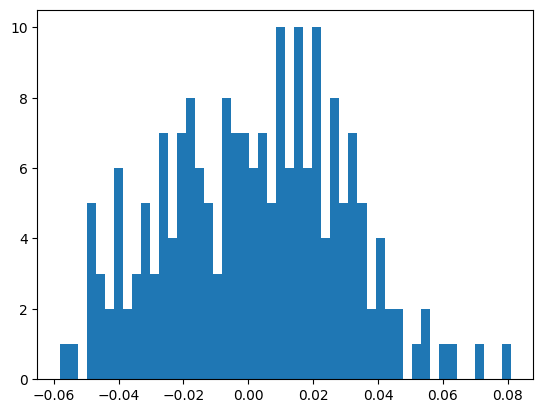

In [14]:
# calculate correlation

all_corr = []
for i in range(test_count_mtx_selected_genes.shape[1]):
    x = test_count_mtx_selected_genes.iloc[:, i].values
    y = pred_avg[:, i]

    if y.std() == 0:
        print(f"Warning: std of predicted values for gene {test_count_mtx_selected_genes.columns[i]} is 0!")

    if x.std() == 0:
        # skip
        print(f"Warning: std of true values for gene {test_count_mtx_selected_genes.columns[i]} is 0! Skipping correlation calculation.")
        continue

    else:
        cor = np.corrcoef(x, y)[0][1]
    all_corr.append(cor)
plt.hist(all_corr, bins=50)

Evaluation metrics

In [15]:
# evaluation metrics

# PCC
print("PCC-10: ", np.mean(sorted(all_corr)[::-1][:10]))
print("PCC-50: ", np.mean(sorted(all_corr)[::-1][:50]))
print("PCC-200: ", np.mean(sorted(all_corr)[::-1][:200]))
# MSE, MAE
print("MSE: ", np.mean((test_count_mtx_selected_genes.values - pred_avg)**2))
print("MAE: ", np.mean(np.abs(test_count_mtx_selected_genes.values - pred_avg)))
# RVD
pred_var = np.var(pred_avg, axis=0)
gt_var = np.var(test_count_mtx_selected_genes.values, axis=0)
print("RVD: ", np.mean((pred_var - gt_var)**2 / gt_var**2))

PCC-10:  0.05699575583467237
PCC-50:  0.03586741693946951
PCC-200:  0.0018874907643379709
MSE:  855.6804
MAE:  23.290495
RVD:  inf


/tmp/ipykernel_430117/3083539355.py:13: RuntimeWarning: divide by zero encountered in divide
  print("RVD: ", np.mean((pred_var - gt_var)**2 / gt_var**2))


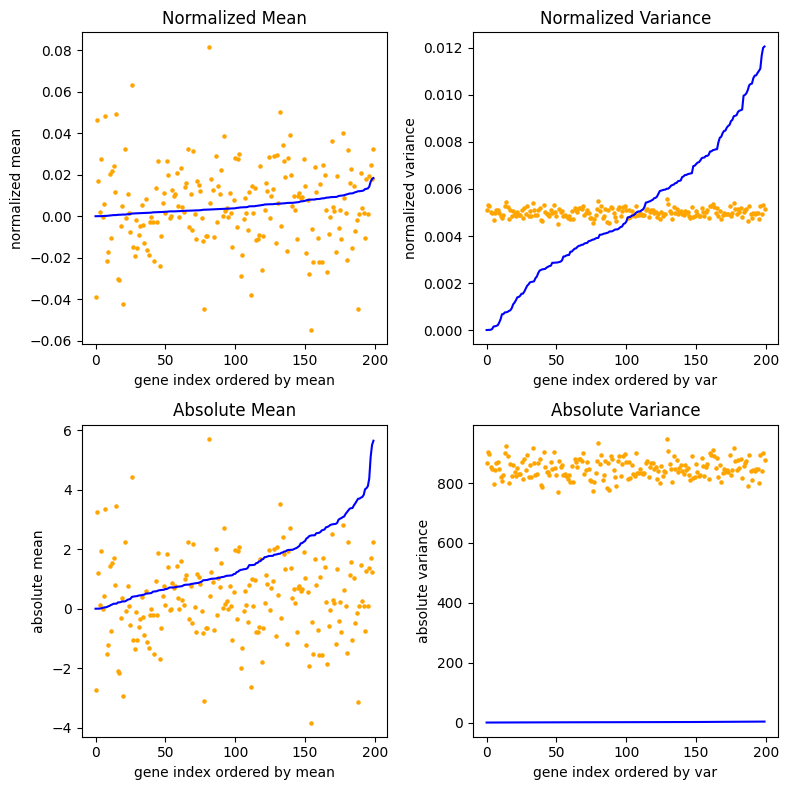

In [18]:
# gene variation curve
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

pred_mean = np.mean(pred_avg, axis=0)
pred_mean = pred_mean / np.sum(pred_mean)
gt_mean = np.mean(test_count_mtx_selected_genes, axis=0)
gt_mean = gt_mean / np.sum(gt_mean)
gt_mean_sorted = np.sort(gt_mean)
pred_mean_sorted = pred_mean[np.argsort(gt_mean)]
axs[0, 0].plot(np.arange(len(gt_mean_sorted)), gt_mean_sorted, label="Ground Truth", c="b")
axs[0, 0].scatter(np.arange(len(pred_mean_sorted)), pred_mean_sorted, s=5, label="Predicted", c="orange")
axs[0, 0].set_title("Normalized Mean")
axs[0, 0].set_xlabel("gene index ordered by mean")
axs[0, 0].set_ylabel("normalized mean")
# axs[0, 0].set_ylim()

pred_mean = np.mean(pred_avg, axis=0)
gt_mean = np.mean(test_count_mtx_selected_genes, axis=0)
gt_mean_sorted = np.sort(gt_mean)
pred_mean_sorted = pred_mean[np.argsort(gt_mean)]
axs[1, 0].plot(np.arange(len(gt_mean_sorted)), gt_mean_sorted, label="Ground Truth", c="b")
axs[1, 0].scatter(np.arange(len(pred_mean_sorted)), pred_mean_sorted, s=5, label="Predicted", c="orange")
axs[1, 0].set_title("Absolute Mean")
axs[1, 0].set_xlabel("gene index ordered by mean")
axs[1, 0].set_ylabel("absolute mean")
# axs[1, 0].set_ylim()


pred_var = np.var(pred_avg, axis=0)
pred_var = pred_var / np.sum(pred_var)
gt_var = np.var(test_count_mtx_selected_genes, axis=0)
gt_var = gt_var / np.sum(gt_var)
gt_var_sorted = np.sort(gt_var)
pred_var_sorted = pred_var[np.argsort(gt_var)]
axs[0, 1].plot(np.arange(len(gt_var_sorted)), gt_var_sorted, label="Ground Truth", c="b")
axs[0, 1].scatter(np.arange(len(pred_var_sorted)), pred_var_sorted, s=5, label="Predicted", c="orange")
axs[0, 1].set_title("Normalized Variance")
axs[0, 1].set_xlabel("gene index ordered by var")
axs[0, 1].set_ylabel("normalized variance")
# axs[0, 1].set_ylim()



pred_var = np.var(pred_avg, axis=0)
gt_var = np.var(test_count_mtx_selected_genes, axis=0)
gt_var_sorted = np.sort(gt_var)
pred_var_sorted = pred_var[np.argsort(gt_var)]
axs[1, 1].plot(np.arange(len(gt_var_sorted)), gt_var_sorted, label="Ground Truth", c="b")
axs[1, 1].scatter(np.arange(len(pred_var_sorted)), pred_var_sorted, s=5, label="Predicted", c="orange")
axs[1, 1].set_title("Absolute Variance")
axs[1, 1].set_xlabel("gene index ordered by var")
axs[1, 1].set_ylabel("absolute variance")
# axs[1, 1].set_ylim()

plt.tight_layout()
plt.show()

In [ ]:
# plot marker genes

Image.MAX_IMAGE_PIXELS = None

img_path = "/storage/hest_data/hs_brain/wsis/"
img_raw = Image.open(img_path + slide_out + ".tif") # change suffix according to image type

x = test_adata.obsm["spatial"][:, 0]
y = test_adata.obsm["spatial"][:, 1]
for gene in [""]: # fill in gene names
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(gene)
    gene_idx = np.where(np.array(selected_genes) == gene)[0][0]

    axs[0].imshow(img_raw)
    color_gt = test_adata[:, test_adata.var_names == gene].X.toarray().flatten()
    im0 = axs[0].scatter(x, y, c=color_gt, s=15, alpha=0.9)
    axs[0].set_title("ground truth")
    fig.colorbar(im0)
    
    axs[1].imshow(img_raw)
    color_pred = pred_avg[:, gene_idx]
    im1 = axs[1].scatter(x, y, c=color_pred, s=15, alpha=0.9) 
    axs[1].set_title("pred")
    fig.colorbar(im1)
    
    plt.show()